<a href="https://colab.research.google.com/github/NimrahImran/ML-ALGORITHEMS/blob/main/xgboost_HR_Employee_Attrition_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATA LOADING

In [ ]:
import pandas as pd
df = pd.read_csv('/content/HR-Employee-Attrition.csv')

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## DATA CLEANING

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
DailyRate,0
DistanceFromHome,0
Education,0
EnvironmentSatisfaction,0
HourlyRate,0
JobInvolvement,0
JobLevel,0
JobSatisfaction,0


In [ ]:
# df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], errors='ignore', inplace=True)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0}) # Encode target
df = pd.get_dummies(df, drop_first=True) # One-hot encode features

## DATA VISUALIZATION (EDA)

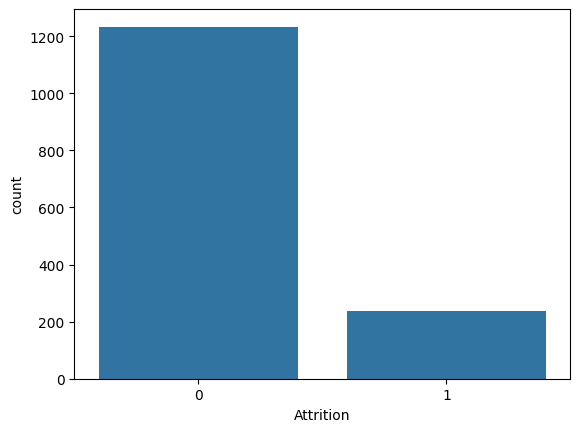

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x=df['Attrition']); plt.show() # Plot target distribution

## FEATURE ENGINEERING
No explicit feature engineering needed beyond one-hot encoding for this dataset.

## TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Attrition', axis=1); y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## MODEL SELECTION

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, learning_rate=0.05) # Low learning_rate

## MODEL TRAINING

In [ ]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## MODEL PREDICTION

In [ ]:
y_pred = model.predict(X_test)

## MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}, F1: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.87, F1: 0.24
Confusion Matrix:
 [[249   6]
 [ 33   6]]


## MODEL TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='f1').fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}, F1 Score: {grid_search.best_score_:.2f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}, F1 Score: 0.44


## CROSS VALIDATION

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(grid_search.best_estimator_, X, y, cv=5, scoring='f1')
print(f"Cross-validation F1 scores: {cv_scores.round(2)}")

Cross-validation F1 scores: [0.24 0.43 0.46 0.49 0.53]


## PIPELINE BUILDING

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipeline = Pipeline([('scaler', StandardScaler()), ('xgb', XGBClassifier(random_state=42))]).fit(X_train, y_train)
print(f"Pipeline Accuracy: {pipeline.score(X_test, y_test):.2f}")

Pipeline Accuracy: 0.88


## MODEL DEPLOYMENT